<a href="https://www.kaggle.com/code/sirinja/heart-disease-prediction?scriptVersionId=238603136" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-failure-prediction/heart.csv


In [2]:
df = pd.read_csv('/kaggle/input/heart-failure-prediction/heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Preliminary Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df['HeartDisease'].value_counts('p')

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

From the output ratio, it shows a balanced dataset.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.iloc[:,0].dtype

dtype('int64')

In [8]:
cat = []
for i in df.columns:
    if df[i].dtype == 'O':
        cat.append(i)
print('The categorical features are',cat)

The categorical features are ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [9]:
df[cat].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [10]:
for col in cat:
    print(f"Unique values in column '{col}':",(df[col].unique()))

Unique values in column 'Sex': ['M' 'F']
Unique values in column 'ChestPainType': ['ATA' 'NAP' 'ASY' 'TA']
Unique values in column 'RestingECG': ['Normal' 'ST' 'LVH']
Unique values in column 'ExerciseAngina': ['N' 'Y']
Unique values in column 'ST_Slope': ['Up' 'Flat' 'Down']


Next step, I will explore the proability in each feature

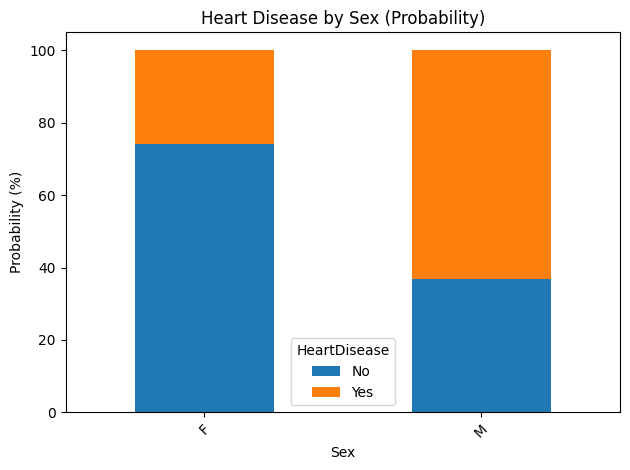

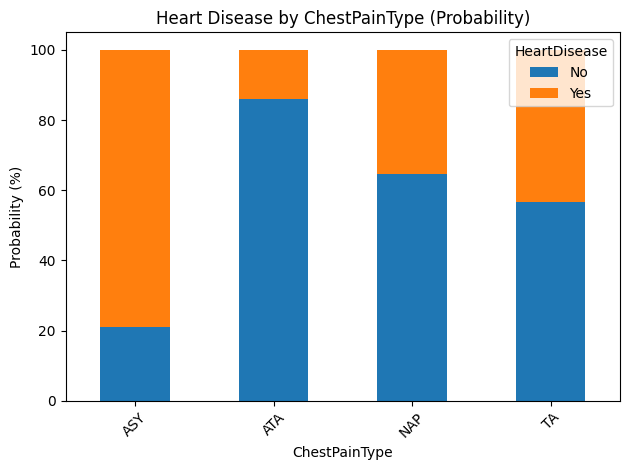

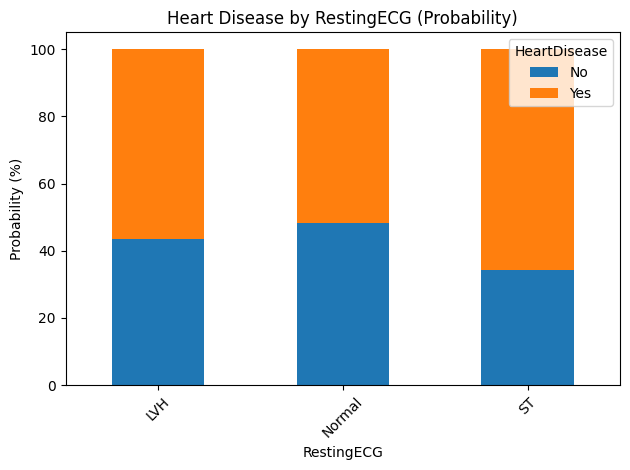

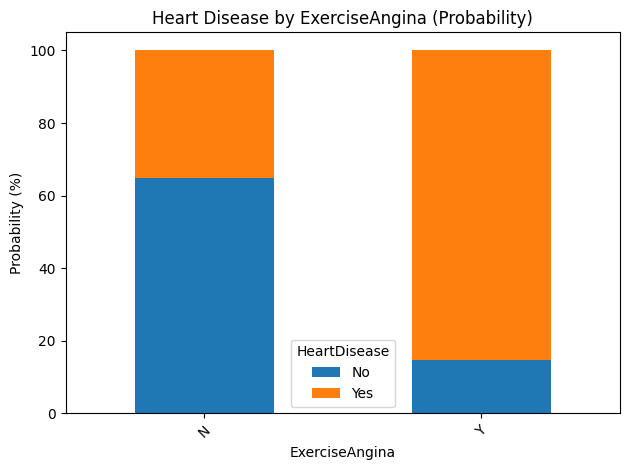

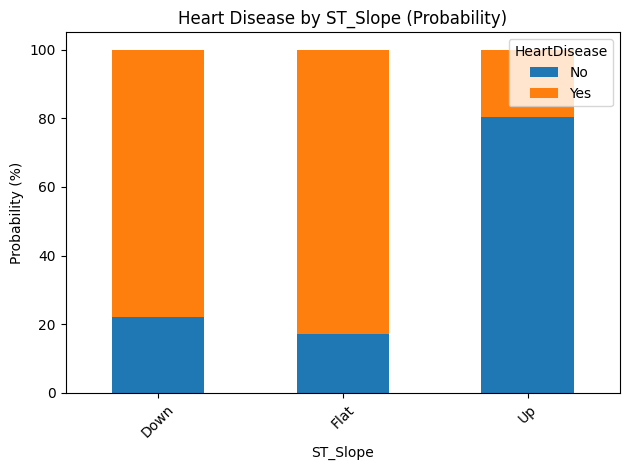

In [11]:
df_plot = df.copy()
df_plot['HeartDisease'] = df_plot['HeartDisease'].map({0: 'No', 1: 'Yes'})

for col in cat:
    pivot_df = df_plot.pivot_table(index=col, columns='HeartDisease', aggfunc='size', fill_value=0)
    pivot_prob = pivot_df.div(pivot_df.sum(axis=1), axis=0) 
    pivot_pct = pivot_prob * 100

    pivot_pct.plot(kind='bar', stacked=True)
    plt.title(f'Heart Disease by {col} (Probability)')
    plt.ylabel('Probability (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Then I will explore the numeric features.

In [12]:
df[df.columns.difference(cat)].describe()

,Age,Cholesterol,FastingBS,HeartDisease,MaxHR,Oldpeak,RestingBP
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,198.799564,0.233115,0.553377,136.809368,0.887364,132.396514
std,9.432617,109.384145,0.423046,0.497414,25.460334,1.066570,18.514154
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,173.250000,0.000000,0.000000,120.000000,0.000000,120.000000
50%,54.000000,223.000000,0.000000,1.000000,138.000000,0.600000,130.000000
75%,60.000000,267.000000,0.000000,1.000000,156.000000,1.500000,140.000000
max,77.000000,603.000000,1.000000,1.000000,202.000000,6.200000,200.000000


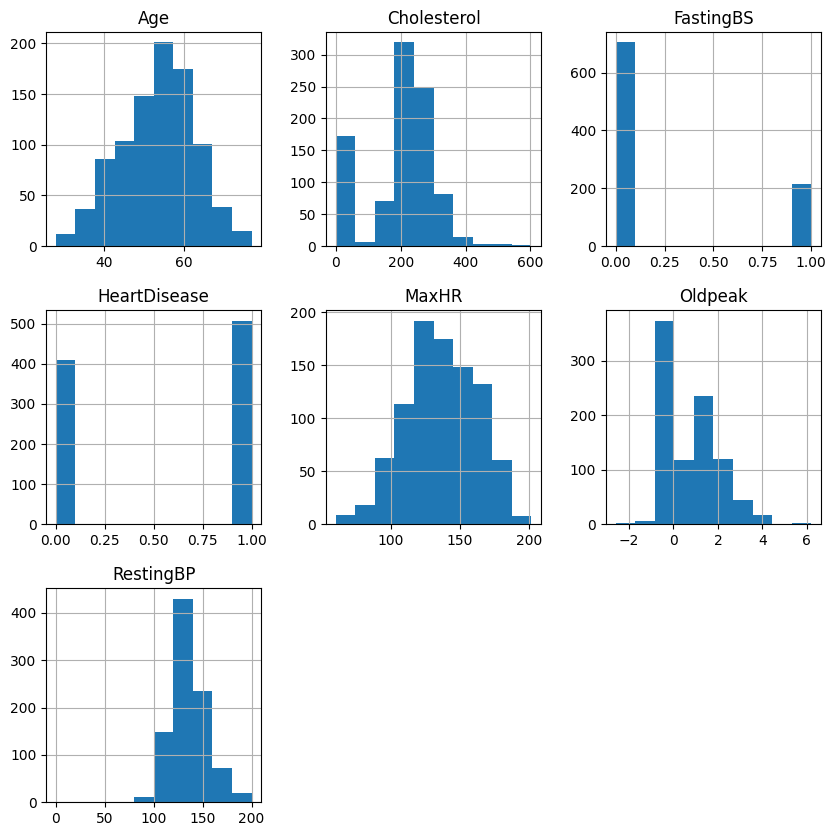

In [13]:
df[df.columns.difference(cat)].hist(figsize=(10,10))
plt.show()

Based on the histogram graph, HeartDisease and FastingBS represent binary categories, not actual numeric values.

## Preprocessing data
Before selecting features, I will scale the numeric features and encode categorical features.

In [14]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# Identify numeric and categorical columns
numeric_columns = df.columns.difference(cat).drop(['HeartDisease', 'FastingBS'])

# Scale numeric columns
scaler = StandardScaler()
scaled_numeric = pd.DataFrame(scaler.fit_transform(df[numeric_columns]), columns=numeric_columns)
LB_encode = LabelEncoder() 
encoded_cat = pd.DataFrame()
for col in cat:
    le = LabelEncoder()
    encoded_cat[col] = le.fit_transform(df[col])

final_data = pd.concat([scaled_numeric, encoded_cat, df[['FastingBS']]], axis=1)

In [15]:
final_data.columns

Index(['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'RestingBP', 'Sex',
       'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope',
       'FastingBS'],
      dtype='object')

In [16]:
from sklearn.model_selection import train_test_split
X = final_data
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=39, stratify=y)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()

rf.fit(X, y)
importance = rf.feature_importances_
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False))

ST_Slope          0.198708
ChestPainType     0.141433
Oldpeak           0.119114
MaxHR             0.112349
Cholesterol       0.109755
Age               0.078836
ExerciseAngina    0.078220
RestingBP         0.076143
Sex               0.035475
FastingBS         0.025518
RestingECG        0.024448
dtype: float64


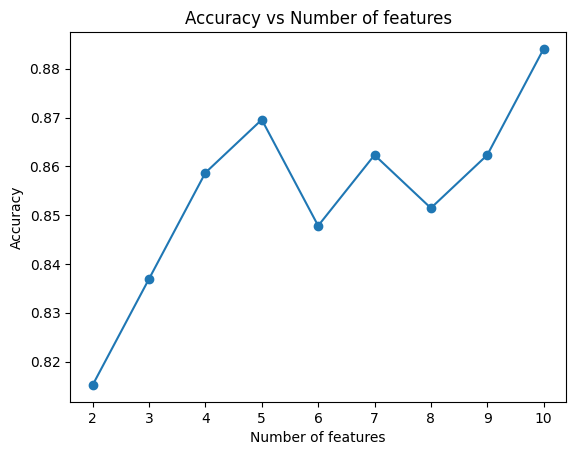

Optimal number of features: 10
Index(['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'RestingBP', 'Sex',
       'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope',
       'FastingBS'],
      dtype='object')


In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score


num_features = range(2,len(feature_importance))
accuracy=[]

for i in num_features:
    #Select the top i most important features
    top_idx=feature_importance.sort_values(ascending=False)[:i].index
    X_train_i=X_train[top_idx]
    X_test_i=X_test[top_idx]
    
    #Train the model
    rf.fit(X_train_i,y_train)
    
    #Evaluate the performance
    y_pred = rf.predict(X_test_i)
    score = accuracy_score(y_test, y_pred)
    accuracy.append(score)

    
# Plot the results
plt.plot(num_features, accuracy,marker='o')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of features')
plt.show()


# Find the optimal number of features
optimal_idx = accuracy.index(max(accuracy))
optimal_num = num_features[optimal_idx]
print('Optimal number of features:', optimal_num)
print(X.iloc[:optimal_idx].columns)

In [19]:
X.iloc[:optimal_idx]

,Age,Cholesterol,MaxHR,Oldpeak,RestingBP,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope,FastingBS
0,-1.433140,0.825070,1.382928,-0.832432,0.410909,1,1,1,0,2,0
1,-0.478484,-0.171961,0.754157,0.105664,1.491752,0,2,1,0,1,0
2,-1.751359,0.770188,-1.525138,-0.832432,-0.129513,1,1,2,0,2,0
3,-0.584556,0.139040,-1.132156,0.574711,0.302825,0,0,1,1,1,0
4,0.051881,-0.034755,-0.581981,-0.832432,0.951331,1,2,1,0,2,0
5,-1.539213,1.282424,1.304332,-0.832432,-0.669935,1,2,1,0,2,0
6,-0.902775,0.349422,1.304332,-0.832432,-0.129513,0,1,1,0,2,0
7,0.051881,0.084157,0.203982,-0.832432,-1.210356,1,1,1,0,2,0


LR: Mean accuracy = 0.83
DT: Mean accuracy = 0.785
RF: Mean accuracy = 0.853
SVM: Mean accuracy = 0.852
Naive: Mean accuracy = 0.845
KNN: Mean accuracy = 0.779


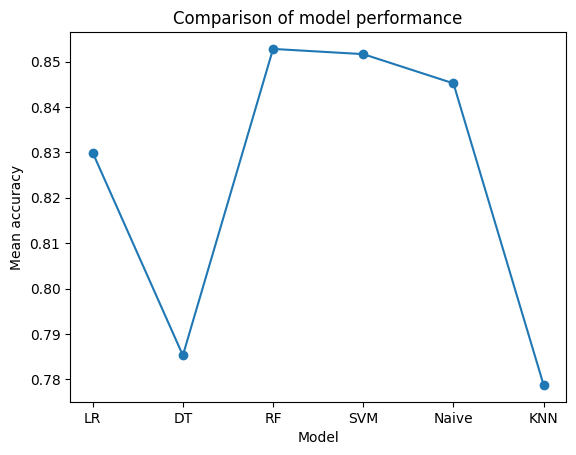

The best model is RF with Mean accuracy = 0.853


In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Define the models
models = [
    ('LR', LogisticRegression()),
    ('DT', DecisionTreeClassifier()),
    ('RF', RandomForestClassifier(bootstrap=True,criterion='gini',max_depth=None)),
    ('SVM', SVC(gamma='auto')),
    ('Naive', GaussianNB()),
    ('KNN',KNeighborsClassifier(n_neighbors=2))
]

# Evaluate each model using cross-validation
results = []
names = []
for name, model in models:
    cv = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    results.append(cv)
    names.append(name)
    print(f"{name}: Mean accuracy = {round(cv.mean(),3)}")

# plot the mean accuracy for each model
plt.plot(names, [result.mean() for result in results], marker='o')

# add labels and title
plt.xlabel('Model')
plt.ylabel('Mean accuracy')
plt.title('Comparison of model performance')
plt.savefig('image9.jpg')
plt.show()

best_idx = np.argmax(np.mean(results, axis=1))
print(f"The best model is {names[best_idx]} with Mean accuracy = {round(np.mean(results[best_idx]),3)}")

In [21]:
models[best_idx]

('RF', RandomForestClassifier())

## Train Best Model

In [22]:
from sklearn import metrics

model = models[best_idx][1]
model.fit(X_train,y_train)
y_train_pred = model.predict(X_train)
print("Accuracy on training set:",round(metrics.accuracy_score(y_train, y_train_pred),3))
y_test_pred = model.predict(X_test)
print("Accuracy on test set:",round(metrics.accuracy_score(y_test, y_test_pred),3))

Accuracy on training set: 1.0
Accuracy on test set: 0.884


In [23]:
print(metrics.classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87       123
           1       0.89      0.91      0.90       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276

